# TS Dynamic Pricing Results Analysis

* Simulation Results
* Load Simulation Results
* Price and Profit
* HDI
* KDE

# Imports 

In [1]:
# Python version
!python --version

Python 3.12.7


In [2]:
# General Imports

import sys
import numpy as np
import pandas as pd
import beautifulplots as bp
import json

import arviz as az
from pathlib import Path
import json
from io import StringIO

import matplotlib.pyplot as plt

sys.path.append(str(Path("..") / "py_modules"))



# Load Simulation Results

In [ ]:
# Sim Results File

###---- case 2 ----#####


# 202605271415
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.05
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.797  p_optest = 2.70
# comment: 
#   - exploration prior to Nk = 15 good gradual convergence prior to NK=15 
sim_results_file = "../data_sim_results/ts_sim_results_case2_202605271415.json" 


### -----copy the desired line (from above) here ------####
sim_results_file = "../data_sim_results/ts_sim_results_case2_202605271415.json" 



In [32]:
# Load
print(f'Loading sim results from {sim_results_file}')

with open(sim_results_file, 'r') as f:
    sim_results_dict = json.load(f)
    
# Load PyMC Traces
traces_dir = Path(sim_results_dict['traces_dir'])

n_traces = sim_results_dict['n_traces']

_traces = [
    az.from_netcdf(traces_dir / f"trace_t{t:03d}.nc")
    for t in range(1, n_traces + 1)
]

print(f'n_traces loaded = {len(_traces)}')

Loading sim results from ../data_sim_results/ts_sim_results_case2_202605271415.json
n_traces loaded = 30


In [33]:
case = sim_results_dict['example_case']
K1 = sim_results_dict["K1"]
K2 = sim_results_dict["K2"]
Nk = sim_results_dict.get("Nk")
Nrounds = sim_results_dict.get("Nrounds")
N_price_repeat = sim_results_dict.get("Nth_new_price") # new variable

price_anchor_1 = sim_results_dict.get("price_anchor_1")
price_anchor_2 = sim_results_dict.get("price_anchor_2")
price_min = sim_results_dict["hyperparameters"]["min_price"]
price_max = sim_results_dict["hyperparameters"]["max_price"]

max_price_change_1 = sim_results_dict.get("max_price_change_1")
max_price_change_2 = sim_results_dict.get("max_price_change_2")
repeat_deviation_1 = sim_results_dict.get("repeat_deviation_1")
repeat_deviation_2 = sim_results_dict.get("repeat_deviation_2")
initial_prices = sim_results_dict["initial_prices"]
sim_variables_str = """
   v_history = v_mean
   a_history = a_mean
   cv_history = cv_mean
   sigma_log_history = sigma_log_mean
   price_optest_history = p_opt_est
"""
print("df_variables",sim_variables_str)
print(f'case = {case}')
print(f'  Nrounds = {Nrounds}')
print(f'  K1 = {K1}')
print(f'  K2 = {K2}')
print(f'  Nk = {Nk}')
print(f'  price_min = {price_min}')
print(f'  price_max = {price_max}')
print(f'  price_anchor_1 = {price_anchor_1}')
print(f'  price_anchor_2 = {price_anchor_2}')
print(f'  initial_prices = {initial_prices}')
print(f'  N_price_repeat = {N_price_repeat}')
print(f'  max_price_change_1 = {max_price_change_1}')
print(f'  max_price_change_2 = {max_price_change_2}')
print(f'  repeat_deviation_1 = {repeat_deviation_1}')
print(f'  repeat_deviation_2 = {repeat_deviation_2}')
print()
# Dataframe of Sim Results
df_ts_summary = pd.read_json(StringIO(sim_results_dict['df_ts_summary_str']), orient='records')

print(df_ts_summary.to_markdown(index=False))

df_variables 
   v_history = v_mean
   a_history = a_mean
   cv_history = cv_mean
   sigma_log_history = sigma_log_mean
   price_optest_history = p_opt_est

case = case2
  Nrounds = 30
  K1 = 1
  K2 = 1
  Nk = 15
  price_min = 2
  price_max = 4.0
  price_anchor_1 = False
  price_anchor_2 = True
  initial_prices = [3.6, 2.3]
  N_price_repeat = None
  max_price_change_1 = 1
  max_price_change_2 = 0.05
  repeat_deviation_1 = None
  repeat_deviation_2 = None

|   n |   price_history |   demand_history |   price_optest_history |   a_history |   v_history |   cv_history |   sigma_log_history |   profit_history |
|----:|----------------:|-----------------:|-----------------------:|------------:|------------:|-------------:|--------------------:|-----------------:|
|   1 |            3.6  |          439.984 |                3.02513 |     3879.89 |     1.67861 |         0.18 |            0.178567 |          951.033 |
|   2 |            3.6  |          387.993 |                2.86432 |     3873

Load Variables and Derived Parameters

In [34]:
# derived parameters
prices_history = df_ts_summary["price_history"]
v_true = sim_results_dict["v_true"]
variable_cost = sim_results_dict["variable_cost"]
fixed_cost =  sim_results_dict["fixed_cost"]
a_true  = sim_results_dict["a_true"]
p1 = sim_results_dict["p1"]

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
    
print(f'p_opt = {round(p_opt,2)}, ... optimal price given true params')
print(f'D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')

p_opt = 2.7, ... optimal price given true params
D_opt = 669.28, ... optimal demand given true params
Profit_opt = 997.91, ... optimal profit given true params
D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6


# Price and Profit

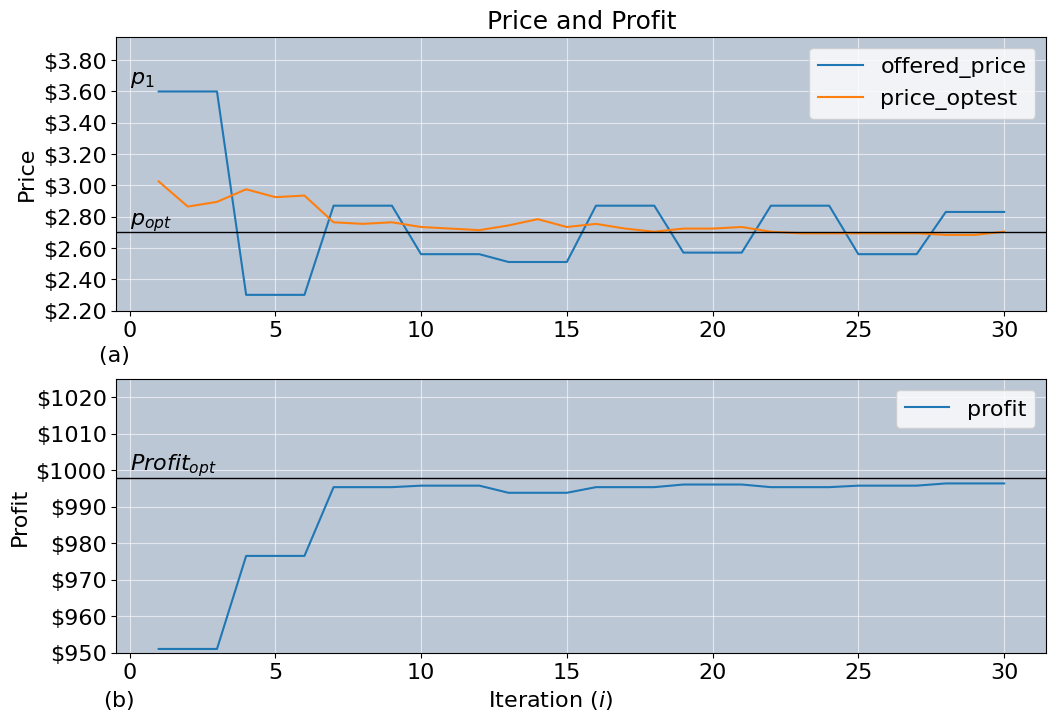

In [35]:
fig, axs = plt.subplots(nrows =2, ncols=1,figsize=(12, 8))

# change variable nambes for better understanding
df_ts_summary["offered_price"] = df_ts_summary["price_history"]
df_ts_summary["price_optest"] = df_ts_summary["price_optest_history"]
df_ts_summary["profit"] = df_ts_summary["profit_history"]

p_opt_str = "$p_{opt}$"
bp.lineplot(
    df_ts_summary, x ="n",
    y = ["offered_price", "price_optest"], 
    y_axis_label='Price',
     x_axis_label="(a)                                                                                                                                   ",
    y_currency="$",
    h_line =[p_opt],
    legend_loc = ("upper right"),
    title = "Price and Profit",
    y_lims = (2.2, 3.95),
    figsize=(12,6),
    ax = axs[0],
    annotate=[  ("$p_1$", (0,3.65)), (p_opt_str, (0, 2.75))] 
    )


background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
axs[0].set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
axs[0].grid(True, color=grid_color, alpha=grid_alpha)
plt.subplots_adjust(wspace=0.25, hspace=0.25)
profit_opt_str = "$Profit_{opt}$"
# Profit
bp.lineplot(df_ts_summary, x="n",
    y = ["profit"],
    y_axis_label='Profit',
    x_axis_label="(b)                                                  Iteration ($i$)                                                                ",
    y_axis_format=".0f",
    y_currency="$",
    y_lims = (950, 1025),
    h_line = Profit_opt,
    figsize=(12,6),
    annotate=[ (profit_opt_str , (0, 1000)) ],
    ax = axs[1]
)
background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
axs[1].set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
axs[1].grid(True, color=grid_color, alpha=grid_alpha)

plt.show()

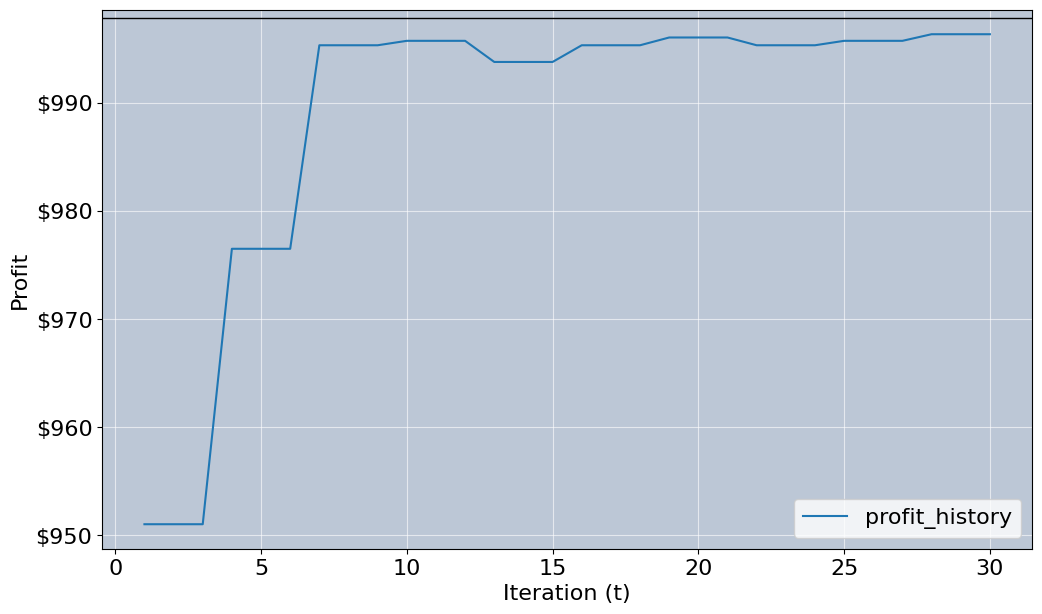

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))
bp.lineplot(df_ts_summary, x="n",
    y = ["profit_history"],
    y_axis_label='Profit',
    x_axis_label='Iteration (t)',
    y_axis_format=".0f",
    y_currency="$",
    h_line = Profit_opt,
    figsize=(12,6),
    ax = ax
)
background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
ax.set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
ax.grid(True, color=grid_color, alpha=grid_alpha)
plt.show()


# HDI Tightening

In [37]:
from utils_plot import plot_hdi_width_over_time

In [38]:

import arviz as az
print(az.__version__)


0.19.0


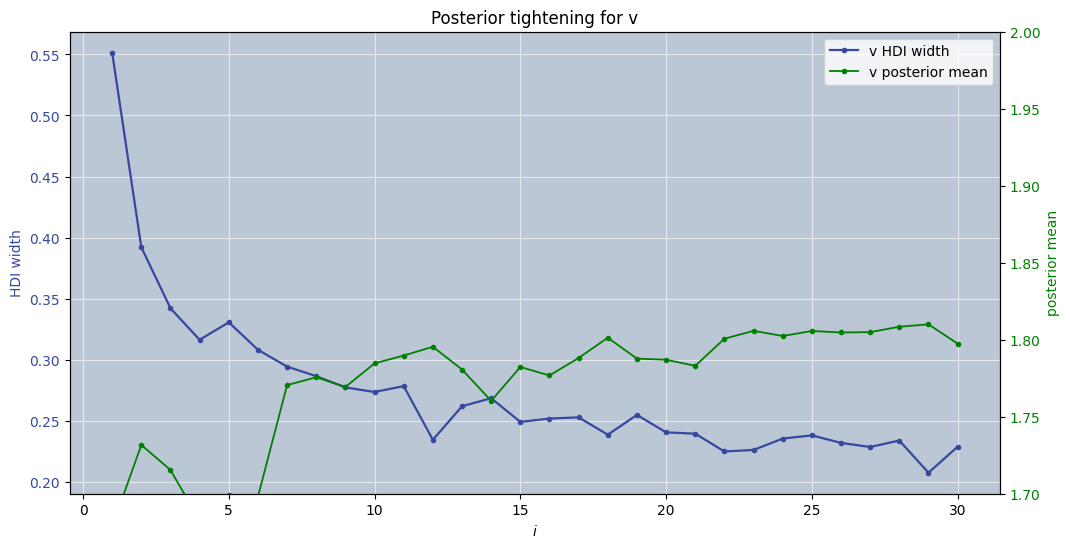

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widths_v = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("v",),
    hdi_prob=0.95,
    overlay_mean=True,
    mean_on_secondary_axis=True,
    secondary_linestyle = "-",
    secondary_marker = ".",
    secondary_line_color="green",
    show_grid=True,
    title="Posterior tightening for v",
    xlabel="$i$",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
    y_lims2=(1.7, 2.0),
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

plt.show()

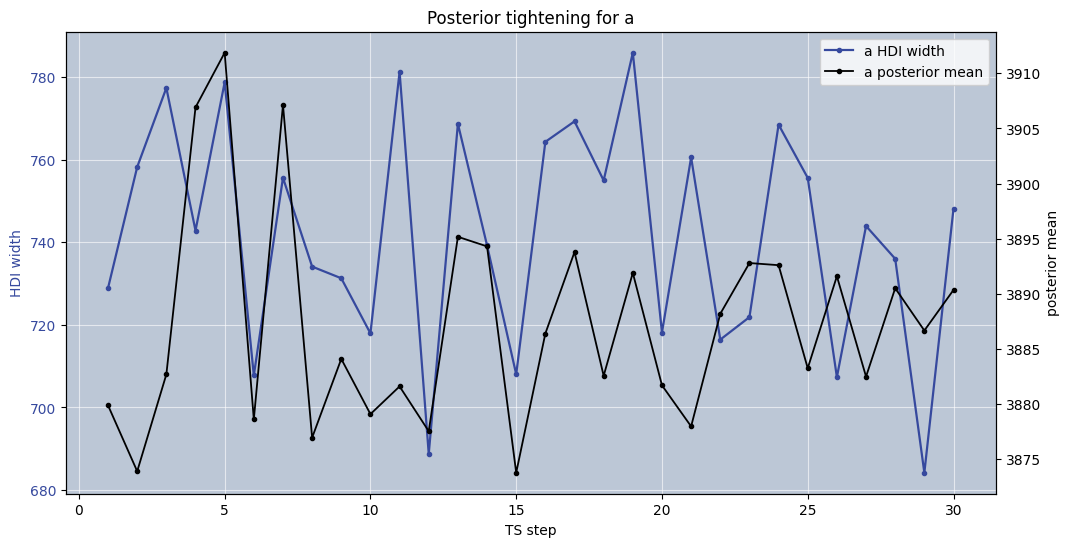

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widths_a = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("a",),
    hdi_prob=0.95,
    overlay_mean=True,
    mean_on_secondary_axis=True,
    secondary_linestyle = "-",
    secondary_marker = ".",
    show_grid=True,
    title="Posterior tightening for a",
    xlabel="TS step",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
)

plt.show()

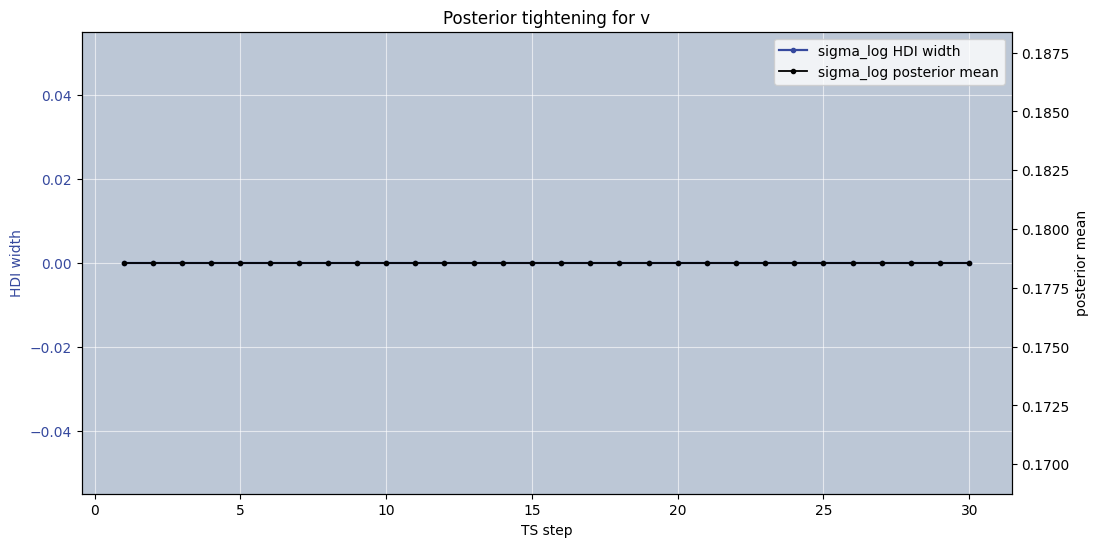

In [41]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widgs_sigma = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("sigma_log",),
    hdi_prob=0.94,
    overlay_mean=True,
    mean_on_secondary_axis=True,
        secondary_linestyle = "-",
    secondary_marker = ".",
    show_grid=True,
    title="Posterior tightening for v",
    xlabel="TS step",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
)

plt.show()

# KDE

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib as mpl
from matplotlib.colors import Normalize

In [43]:
from utils_plot import plot_kde_densities_at_prices

#### demand

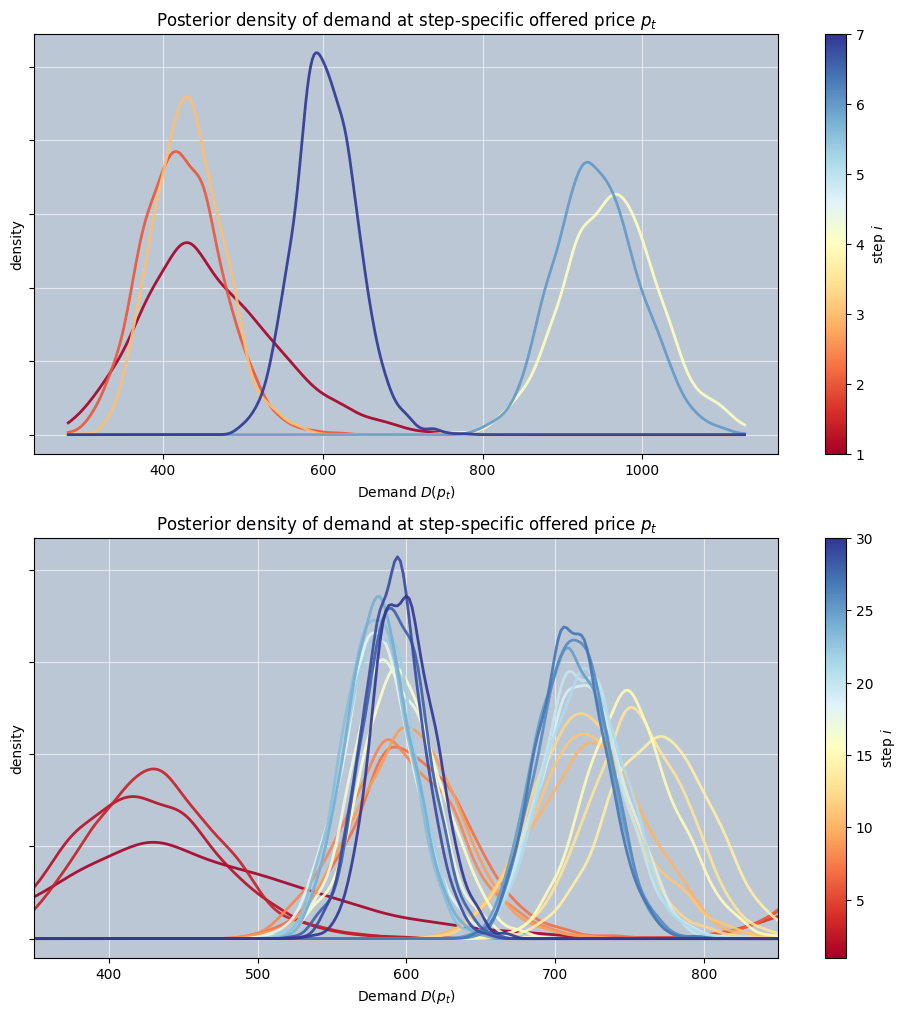

In [44]:
# demand
fig, axs = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))
# t starts at 1
plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    kde_plot_variable="demand",
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    ax=axs[0],
    cmap_name="RdYlBu",
    t_min=1,
    t_max=None,
    t_indices=[1,2,3,4,6,7,37,38],      #  price is hopping +/- around p_optext, function of price
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    )

#axs[0].set_xlim(350, 850)
axs[0].tick_params(axis='y', labelleft=False)

# t 1, 2 ... 30
plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    kde_plot_variable="demand",
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    ax=axs[1],
    cmap_name="RdYlBu",
    t_min=1,
    t_max=None,
    #t_indices=[1,2,3,4,5,6,7,8,9,25,26,30],      # example: [1, 3, 5, 10]
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    )

axs[1].set_xlim(350, 850)
axs[1].tick_params(axis='y', labelleft=False)

plt.show()

#### revenue
- revenue is subject to p_optest +/- changes

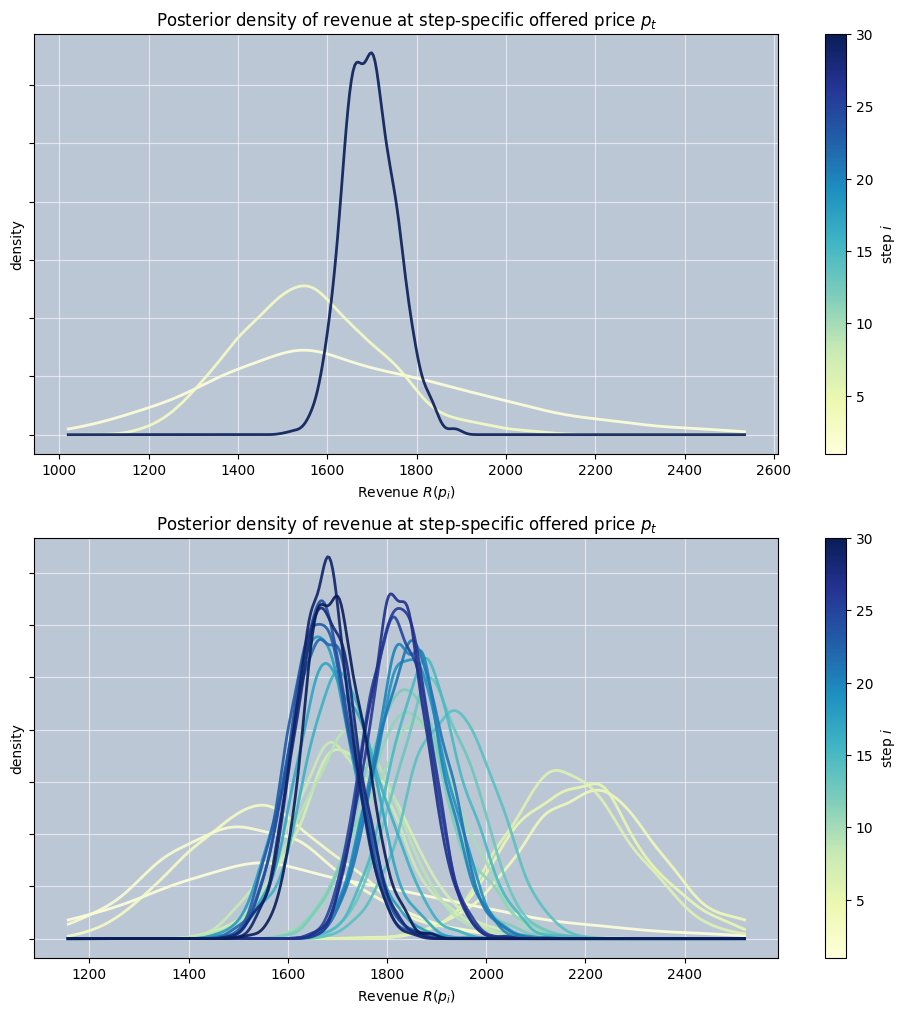

In [45]:
# revenue
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))
t_max=None
ax[0] = plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[0],
    kde_plot_variable="revenue",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_max = None,
    t_indices = [1, 3, 30],
    cmap_name="YlGnBu",   # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[0].set_xlim(1000, 2300) 
ax[0].tick_params(axis='y', labelleft=False)


ax[1] = plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[1],
    kde_plot_variable="revenue",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_max = None,
    cmap_name="YlGnBu",   # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[1].set_xlim(1300, 2100) 
ax[1].tick_params(axis='y', labelleft=False)


plt.show()

### price

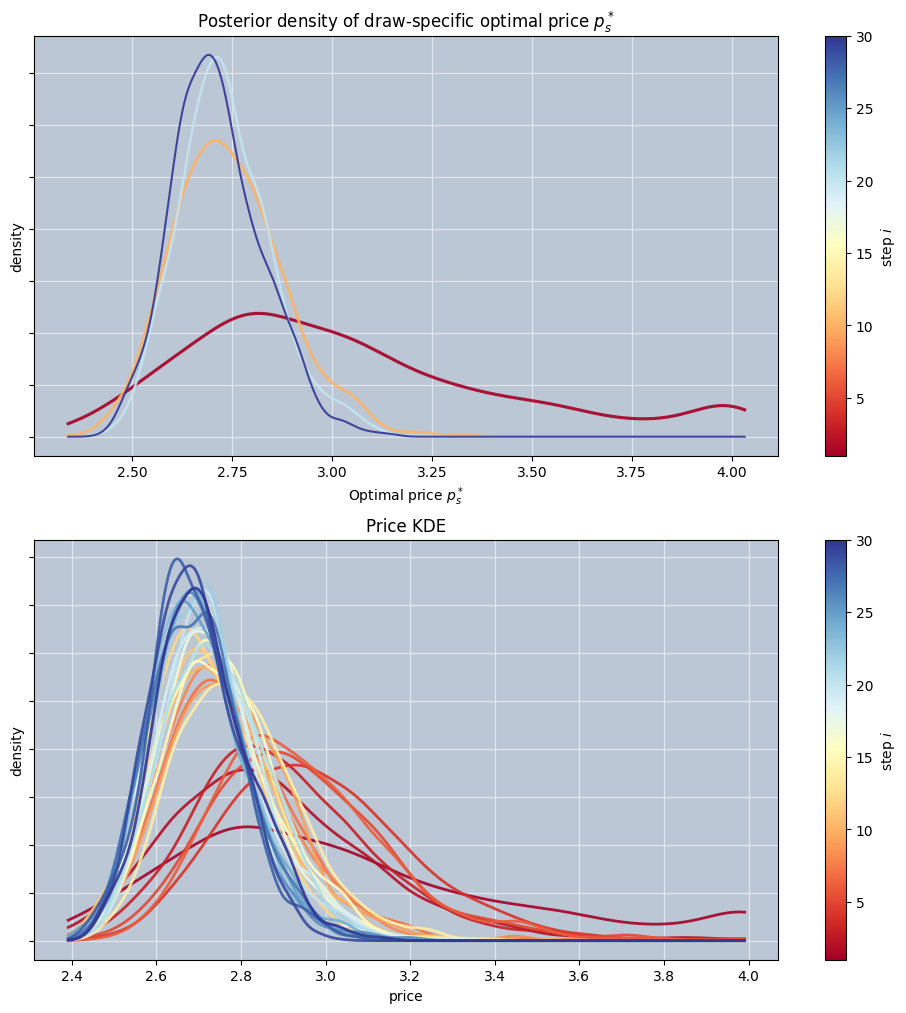

In [46]:
# price
# t starts at 1
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))


ax[0]=plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[0],
    kde_plot_variable="optimal_price",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    price_min=price_min,
    price_max=price_max,
    t_indices = [1,10,20,30,40],
    #colors=["#E2523D", "#FBF8BD", "#36499E"],
    closed_form_optimal_price=False,
    cmap_name= "RdYlBu",  # "YlGnBu", "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6", # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    linewidth_progression=True,
    linewidth_min=1.5,
    linewidth_max=2.25,
    reverse_linewidth_progression=True

)
#ax[0].set_xlim(2, 3.8) 
ax[0].tick_params(axis='y', labelleft=False)

ax[1]=plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[1],
    title="Price KDE",
    xlabel="price",
    kde_plot_variable="optimal_price",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    price_min=price_min,
    price_max=price_max,
    closed_form_optimal_price=False,
    cmap_name="RdYlBu",  # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[0].set_xlim(2, 3.8) 
ax[1].tick_params(axis='y', labelleft=False)

plt.show()


KDE tail bump density (early rounds) ... above
The graph above, posterior density of offered price $p^*$ shows a "boundary pile up" effect on the right edge of the tail. This is a KDE graph artifact. In the early parts of the TS simulation the posterior is wide with non-neglidgable density to the right of the price_max. As the posterior tightens and centers on the optimum price, the tail smooths out since most of the desity is closer to the optimum price with less density in the tails, and little beyound the maximum price.

#### profit

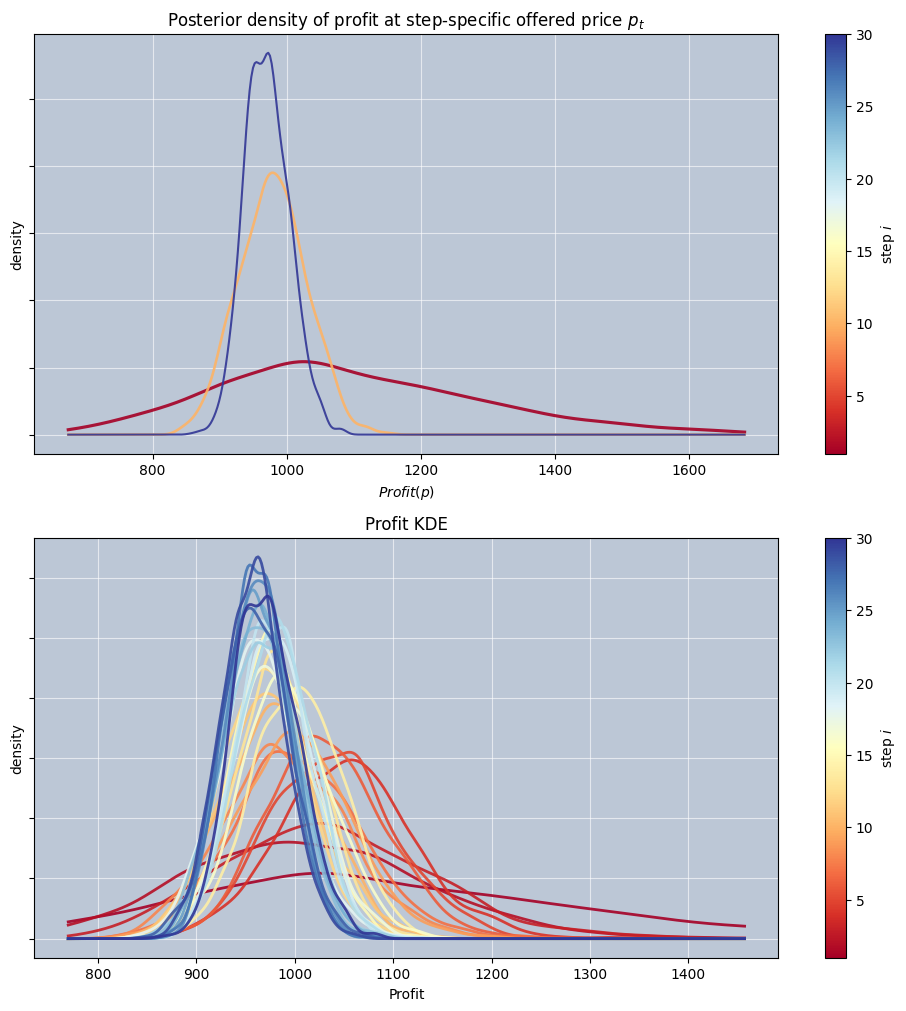

In [47]:
# profit
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))

ax[0]=plot_kde_densities_at_prices(
    traces=_traces,
    ax = ax[0],
    prices_history=prices_history,
    kde_plot_variable="profit",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_indices = [1, 10, 30,40],
    cmap_name="RdYlBu",   # "viridis_r", "RdYlBu", "YlGnBu"
    background_color="#bcc7d6", # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    linewidth_progression=True,
    linewidth_min=1.5,
    linewidth_max=2.25,
    reverse_linewidth_progression=True
)
ax[0].tick_params(axis='y', labelleft=False)


ax[1]=plot_kde_densities_at_prices(
    traces=_traces,
    ax = ax[1],
    prices_history=prices_history,
    title = "Profit KDE",
    xlabel="Profit",
    kde_plot_variable="profit",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    cmap_name="RdYlBu",   # "viridis_r", "RdYlBu", YlGnBu, Blues, RdGnBu
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax.set_xlim(825, 1200) 
ax[1].tick_params(axis='y', labelleft=False)
plt.show()